In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl

# path_to_folder = r"C:\Users\clara\Desktop\special_course\ds003838"
path_to_folder = r"C:\Users\cdd\Documents\Uni\Special_course\ds003838-download"

subnums = np.arange(32, 99, 1)
subnums = np.delete(subnums, np.where((subnums == 37) | (subnums == 66) | (subnums == 94))) # remove subjects with missing data
subject_folders = [f'sub-0{i}' for i in subnums]


In [2]:
# Initialize an empty list to store DataFrames
all_subjects_events = []

for i in subject_folders:
    folder_path = os.path.join(path_to_folder, i, "pupil")
    filename = i + "_task-memory_events.tsv"
    file_path = os.path.join(folder_path, filename)

    # Read each CSV file into a DataFrame
    try:
        df = pd.read_csv(file_path, sep='\t', usecols=['timestamp', 'label'])
        all_subjects_events.append(df)
        
    except FileNotFoundError:
        print(f"File not found: {file_path}")

    except:
        print(file_path)

for i in all_subjects_events:
    print(i.head())

print(len(all_subjects_events))

File not found: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-037\pupil\sub-037_task-memory_events.tsv
File not found: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-066\pupil\sub-066_task-memory_events.tsv
File not found: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-094\pupil\sub-094_task-memory_events.tsv
      timestamp   label
0  1.603518e+09  500113
1  1.603518e+09  500213
2  1.603518e+09  500313
3  1.603518e+09  500413
4  1.603518e+09  500513
      timestamp   label
0  1.603534e+09  500105
1  1.603534e+09  500205
2  1.603534e+09  500305
3  1.603534e+09  500405
4  1.603534e+09  500505
      timestamp   label
0  1.603702e+09  500109
1  1.603702e+09  500209
2  1.603702e+09  500309
3  1.603702e+09  500409
4  1.603702e+09  500509
      timestamp   label
0  1.603783e+09  500109
1  1.603783e+09  500209
2  1.603783e+09  500309
3  1.603783e+09  500409
4  1.603783e+09  500509
      timestamp   label
0  1.603795e+09  500109
1  1.603795e+

**For one subject:**
1. Pre processing
    - select data from the dominant eye
    - if conf. score <80%, NA
    - data broken into epochs corresponding to the time intervals starting 2s before the presentation of the first digit in the sequence and ending 3s after the presentation of the last digit in the sequence
    - MAD for rapid pupil size changes (if >16 std, NA)
    - Blinks [-100, 100] - NA
    - Trials with >50% NA - removed
    - Participants with <6 trials - removed
    - NA were linearly interpolated and smoothed with 5 points moving average
    - resulting pupil size was baseline normalized by subtracting the mean absolute value in the interval of 2 s before the presentation of the first digit in the sequence
2. Plotting 

3. Compare to thesis

In [3]:
# Initialize an empty list to store DataFrames
all_subjects_pupil = []

for i in subject_folders:
    folder_path = os.path.join(path_to_folder, i, "pupil")
    filename = i + "_task-memory_pupil.tsv"
    file_path = os.path.join(folder_path, filename)
    
    # Read CSV file into a DataFrame
    try:
        df = pd.read_csv(file_path, sep='\t', usecols=['pupil_timestamp', 'diameter', 'confidence', 'blink'])
        all_subjects_pupil.append(df)
        print(f"File loaded: {file_path}")
        
    except FileNotFoundError:
        print(f"File not found: {file_path}")

    except Error as e:
        print(f"{e} loading {file_path}")


File loaded: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-032\pupil\sub-032_task-memory_pupil.tsv
File loaded: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-033\pupil\sub-033_task-memory_pupil.tsv
File loaded: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-034\pupil\sub-034_task-memory_pupil.tsv
File loaded: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-035\pupil\sub-035_task-memory_pupil.tsv
File loaded: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-036\pupil\sub-036_task-memory_pupil.tsv
File not found: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-037\pupil\sub-037_task-memory_pupil.tsv
File loaded: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-038\pupil\sub-038_task-memory_pupil.tsv
File loaded: C:\Users\cdd\Documents\Uni\Special_course\ds003838-download\sub-039\pupil\sub-039_task-memory_pupil.tsv
File loaded: C:\Users\cdd\Documents\Uni\Special_course\ds0038

In [4]:
for i in all_subjects_pupil:
    print(i.head())

   pupil_timestamp  confidence   diameter  blink
0     1.603518e+09    0.999383  33.347157      0
1     1.603518e+09    1.000000  33.346352      0
2     1.603518e+09    0.809907  34.599331      0
3     1.603518e+09    0.817906  34.599821      0
4     1.603518e+09    0.999549  33.303163      0
   pupil_timestamp  confidence   diameter  blink
0     1.603534e+09    0.999805  29.931720      0
1     1.603534e+09    1.000000  29.932348      0
2     1.603534e+09    1.000000  31.640831      0
3     1.603534e+09    0.999497  31.638402      0
4     1.603534e+09    0.999897  30.347747      0
   pupil_timestamp  confidence   diameter  blink
0     1.603702e+09    1.000000  37.776237      0
1     1.603702e+09    0.999254  37.775493      0
2     1.603702e+09    0.998564  41.223311      0
3     1.603702e+09    1.000000  41.226822      0
4     1.603702e+09    0.998907  41.148751      0
   pupil_timestamp  confidence   diameter  blink
0     1.603782e+09    0.998887  29.369350      0
1     1.603782e+09  

In [5]:
print(len(all_subjects_pupil))

for i in all_subjects_pupil:
    # NA for confidence below 80%
    replaced_values = i['confidence'] < 0.8
    i.loc[replaced_values, 'diameter'] = np.nan

    # Count the number of replaced values
    num_nan = replaced_values.sum()
    # Print the result
    print(f"{num_nan} out of {len(i)} ({num_nan*100/len(i)}%) values were replaced by NaN.")
    print(i.head(10))

64
596200 out of 4448766 (13.401469081538567%) values were replaced by NaN.
   pupil_timestamp  confidence   diameter  blink
0     1.603518e+09    0.999383  33.347157      0
1     1.603518e+09    1.000000  33.346352      0
2     1.603518e+09    0.809907  34.599331      0
3     1.603518e+09    0.817906  34.599821      0
4     1.603518e+09    0.999549  33.303163      0
5     1.603518e+09    1.000000  33.302441      0
6     1.603518e+09    0.814313  34.480656      0
7     1.603518e+09    0.822792  34.481238      0
8     1.603518e+09    1.000000  33.608562      0
9     1.603518e+09    0.999539  33.609258      0
1261471 out of 5798750 (21.75418840267299%) values were replaced by NaN.
   pupil_timestamp  confidence   diameter  blink
0     1.603534e+09    0.999805  29.931720      0
1     1.603534e+09    1.000000  29.932348      0
2     1.603534e+09    1.000000  31.640831      0
3     1.603534e+09    0.999497  31.638402      0
4     1.603534e+09    0.999897  30.347747      0
5     1.603534e+09

we want the data broken into epochs corresponding to the time intervals starting 2s before the presentation of the first digit in the sequence and ending 3s after the presentation of the last digit in the sequence. so we need to identify the timestamp of the first and last and make epochs. we probably want to difirientiate by load and by memory/load. 

In [ ]:
import pandas as pd

# Helper to extract condition and load from a label string
def parse_label(label):
    label = str(label)
    condition = "control" if label.startswith("50") else "memory"
    load = int(label[4:6])  # 05, 09, 13
    return condition, load

def apply_speed_mad_filter(pupil_epoch, time_col="pupil_timestamp", signal_col="diameter", threshold_factor=16):
    # Compute time difference (in seconds)
    dt = np.diff(pupil_epoch[time_col], prepend=pupil_epoch[time_col].iloc[0])
    dt[dt <= 0] = np.nan  # Remove zero or negative dt to prevent spikes

    # Compute dilation speed: absolute change in diameter / time difference
    speed = np.abs(np.diff(pupil_epoch[signal_col], prepend=pupil_epoch[signal_col].iloc[0])) / dt
    # Mask speed where either signal or time was NaN
    nan_mask = pupil_epoch[signal_col].isna() | pd.isna(dt)
    speed[nan_mask] = np.nan

    # Compute MAD and median
    median_speed = np.nanmedian(speed)
    mad_speed = np.nanmedian(np.abs(speed - median_speed))

    # Threshold
    threshold = median_speed + threshold_factor * mad_speed

    # Invalidate points with too high speed
    pupil_epoch.loc[speed > threshold, signal_col] = np.nan

    return pupil_epoch

# Group consecutive labels belonging to the same trial
def group_trials(events_df):
    '''
    Group consecutive labels belonging to the same trial. Each trial is a sequence of digits (of length 5, 9 or 13),
    in either the control or memory condition
    Input:
        events_df: DataFrame with columns ["timestamp", "label"]
    Output:
        List of trials, where each trial is a tuple (condition, load, trial_rows), where
        - condition is either "control" or "memory"
        - load is the number of digits in the trial (5, 9 or 13)
        - trial_rows is a DataFrame with columns ["timestamp", "label", "condition", "load"] containing the rows of the trial
    '''
    # Ensure label is string for indexing
    events_df = events_df.copy()
    events_df["label"] = events_df["label"].astype(str)

    # Create a boolean mask for where new trials start (labels with digit 01)
    new_trial_mask = events_df["label"].str[2:4] == "01"

    # Assign trial numbers using cumulative sum of new trial indicators
    events_df["trial_id"] = new_trial_mask.cumsum()

    # Extract metadata: condition and load
    events_df["condition"] = np.where(events_df["label"].str.startswith("50"), "control", "memory")
    events_df["load"] = events_df["label"].str[4:6].astype(int)

    # Group by trial
    grouped = events_df.groupby("trial_id")

    # Collect trials as list of DataFrames with metadata
    trials = []
    for trial_id, group in grouped:
        condition = group["condition"].iloc[0]
        load = group["load"].iloc[0]
        trials.append((condition, load, group.drop(columns="trial_id")))

    return trials


# Create epochs
def create_epochs(subject_events, subject_pupil):
    subject_events = subject_events.sort_values("timestamp")
    trials = group_trials(subject_events)

    epochs = []

    for condition, load, trial_rows in trials:
        # Convert trial to DataFrame
        trial_df = pd.DataFrame(trial_rows)

        start_time = trial_df["timestamp"].iloc[0] - 2  # 2s before first digit
        end_time = trial_df["timestamp"].iloc[-1] + 3  # 3s after last digit

        # Select pupil data within this epoch
        pupil_epoch = subject_pupil[
            (subject_pupil["pupil_timestamp"] >= start_time) &
            (subject_pupil["pupil_timestamp"] <= end_time)
        ].copy()

        pupil_epoch["condition"] = condition
        pupil_epoch["load"] = load
        pupil_epoch["epoch_start"] = start_time
        pupil_epoch["epoch_end"] = end_time

        epochs.append(pupil_epoch)

    return epochs

# Create epochs and FILTER
def create_epochs_v2(subject_events, subject_pupil):
    subject_events = subject_events.sort_values("timestamp")
    trials = group_trials(subject_events)
    epochs = []

    for condition, load, trial_rows in trials:
        # Convert trial to DataFrame
        trial_df = pd.DataFrame(trial_rows)

        start_time = trial_df["timestamp"].iloc[0] - 2  # 2s before first digit
        end_time = trial_df["timestamp"].iloc[-1] + 3  # 3s after last digit

        # Select pupil data within this epoch
        pupil_epoch = subject_pupil[
            (subject_pupil["pupil_timestamp"] >= start_time) &
            (subject_pupil["pupil_timestamp"] <= end_time)
        ].copy()
        
        if pupil_epoch.empty:
            continue
        
        # Step 1: Apply Geller-style speed MAD filter. This is different from the thesis
        pupil_epoch = apply_speed_mad_filter(pupil_epoch)
        
        # Step 2: Handle blink: Set 'diameter' to NaN where blinks occur (±100ms)
        blink_times = pupil_epoch.loc[pupil_epoch['blink'] == 1, 'pupil_timestamp'].values
        if len(blink_times) > 0:
            ts = pupil_epoch['pupil_timestamp'].values[:, np.newaxis]
            in_blink = ((ts >= blink_times - 0.1) & (ts <= blink_times + 0.1)).any(axis=1)
            pupil_epoch.loc[in_blink, 'diameter'] = np.nan
        
        # Step 3: Remove trial if more than 50% missing
        missing_ratio = pupil_epoch["diameter"].isna().mean()
        if missing_ratio > 0.5:
            # I should somehow markt these trials because I will need to remove them from the EEG analysis too, since i am doing CCA per subject and trial
            # Same with removed subjects
            continue
        
        # Step 4: Interpolate and smooth
        pupil_epoch["diameter"] = pupil_epoch["diameter"].interpolate(method="linear", limit_direction="both")
        pupil_epoch["diameter"] = pupil_epoch["diameter"].rolling(window=5, center=True, min_periods=1).mean()
        
        # Convert timestamp (in seconds) to datetime for resampling
        pupil_epoch['pupil_datetime'] = pd.to_datetime(pupil_epoch['pupil_timestamp'], unit='s')

        # Step 5: Baseline normalization using 2s before first digit
        start_time = pupil_epoch['pupil_datetime'].min()
        baseline_interval = pupil_epoch[(pupil_epoch['pupil_datetime'] >= start_time) & 
                                    (pupil_epoch['pupil_datetime'] < start_time + pd.Timedelta(seconds=2))]
        
        # Compute the mean of pupil size during the baseline interval
        baseline_mean = baseline_interval['diameter'].mean()
        pupil_epoch["diameter"] = pupil_epoch["diameter"] - baseline_mean
        
        pupil_epoch.set_index('pupil_datetime', inplace=True)
        # Step 5: Resample by using a time-based approach (10 Hz = one data point every 100ms)
        pupil_epoch = pupil_epoch.resample("100ms").mean()

        # Fill any NaNs created during resampling
        pupil_epoch["diameter"] = pupil_epoch["diameter"].ffill().bfill()

        # Add metadata
        pupil_epoch["condition"] = condition
        pupil_epoch["load"] = load
        pupil_epoch["epoch_start"] = start_time
        pupil_epoch["epoch_end"] = end_time
        pupil_epoch["time"] = (((pupil_epoch.index - pupil_epoch.index[0]) / pd.Timedelta(seconds=1)) - 2).round(1) # Convert to seconds relative to the start of the epoch
        pupil_epoch.index = pupil_epoch["time"]


        epochs.append(pupil_epoch)
        
    return epochs

In [24]:
epochs_per_sub = []
for i in range(len(all_subjects_events)):
    print(f"-----------Preprocessing subject {i}-------------")
    # Skip if pupil data is empty
    epochs = create_epochs_v2(all_subjects_events[i], all_subjects_pupil[i])
    if len(epochs) < 6: #the meximum should be 162 epochs (3+12+3)*9
        print(f"⚠️ Subject {i} excluded: too few valid trials")
        continue
    # Example: print the first epoch
    print(epochs[0].head())
    epochs_per_sub.append(epochs)

-----------Preprocessing subject 0-------------
      pupil_timestamp  confidence  diameter  blink condition  load  \
time                                                                 
-2.0     1.603518e+09    0.940203  4.803390    0.0   control    13   
-1.9     1.603518e+09    0.912064  4.726322    0.0   control    13   
-1.8     1.603518e+09    0.921794  4.195045    0.0   control    13   
-1.7     1.603518e+09    0.933347  3.953999    0.0   control    13   
-1.6     1.603518e+09    0.922845  3.309866    0.0   control    13   

                       epoch_start     epoch_end  time  
time                                                    
-2.0 2020-10-24 05:36:45.290319920  1.603518e+09  -2.0  
-1.9 2020-10-24 05:36:45.290319920  1.603518e+09  -1.9  
-1.8 2020-10-24 05:36:45.290319920  1.603518e+09  -1.8  
-1.7 2020-10-24 05:36:45.290319920  1.603518e+09  -1.7  
-1.6 2020-10-24 05:36:45.290319920  1.603518e+09  -1.6  
-----------Preprocessing subject 1-------------
      pupil_ti

C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarning: All-NaN slice encountered
  median_speed = np.nanmedian(speed)
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:23: RuntimeWarning: All-NaN slice encountered
  mad_speed = np.nanmedian(np.abs(speed - median_speed))
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarning: All-NaN slice encountered
  median_speed = np.nanmedian(speed)
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:23: RuntimeWarning: All-NaN slice encountered
  mad_speed = np.nanmedian(np.abs(speed - median_speed))
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarning: All-NaN slice encountered
  median_speed = np.nanmedian(speed)
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:23: RuntimeWarning: All-NaN slice encountered
  mad_speed = np.nanmedian(np.abs(speed - median_speed))
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarn

      pupil_timestamp  confidence  diameter  blink condition  load  \
time                                                                 
-2.0     1.604746e+09    0.999630  0.029129    0.0   control     5   
-1.9     1.604746e+09    0.999334  0.231033    0.0   control     5   
-1.8     1.604746e+09    0.998454  0.804120    0.0   control     5   
-1.7     1.604746e+09    0.997184  0.576898    0.0   control     5   
-1.6     1.604746e+09    0.995630 -0.080643    0.0   control     5   

                       epoch_start     epoch_end  time  
time                                                    
-2.0 2020-11-07 10:54:15.098589897  1.604746e+09  -2.0  
-1.9 2020-11-07 10:54:15.098589897  1.604746e+09  -1.9  
-1.8 2020-11-07 10:54:15.098589897  1.604746e+09  -1.8  
-1.7 2020-11-07 10:54:15.098589897  1.604746e+09  -1.7  
-1.6 2020-11-07 10:54:15.098589897  1.604746e+09  -1.6  
-----------Preprocessing subject 14-------------
      pupil_timestamp  confidence  diameter  blink condition 

C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarning: All-NaN slice encountered
  median_speed = np.nanmedian(speed)
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:23: RuntimeWarning: All-NaN slice encountered
  mad_speed = np.nanmedian(np.abs(speed - median_speed))


⚠️ Subject 44 excluded: too few valid trials
-----------Preprocessing subject 45-------------
      pupil_timestamp  confidence  diameter  blink condition  load  \
time                                                                 
-2.0     1.607493e+09    0.998839 -0.601949    0.0   control    13   
-1.9     1.607493e+09    0.998848 -0.579489    0.0   control    13   
-1.8     1.607493e+09    0.998851 -0.317998    0.0   control    13   
-1.7     1.607493e+09    0.998795  0.037462    0.0   control    13   
-1.6     1.607493e+09    0.998883  0.318071    0.0   control    13   

                       epoch_start     epoch_end  time  
time                                                    
-2.0 2020-12-09 05:55:30.228149891  1.607493e+09  -2.0  
-1.9 2020-12-09 05:55:30.228149891  1.607493e+09  -1.9  
-1.8 2020-12-09 05:55:30.228149891  1.607493e+09  -1.8  
-1.7 2020-12-09 05:55:30.228149891  1.607493e+09  -1.7  
-1.6 2020-12-09 05:55:30.228149891  1.607493e+09  -1.6  
-----------Prepr

C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarning: All-NaN slice encountered
  median_speed = np.nanmedian(speed)
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:23: RuntimeWarning: All-NaN slice encountered
  mad_speed = np.nanmedian(np.abs(speed - median_speed))


      pupil_timestamp  confidence  diameter  blink condition  load  \
time                                                                 
-2.0     1.608203e+09    0.998774  1.361039    0.0   control     9   
-1.9     1.608203e+09    0.998842  1.582786    0.0   control     9   
-1.8     1.608203e+09    0.998957  1.352456    0.0   control     9   
-1.7     1.608203e+09    0.998851  1.072944    0.0   control     9   
-1.6     1.608203e+09    0.998761  0.948341    0.0   control     9   

                       epoch_start     epoch_end  time  
time                                                    
-2.0 2020-12-17 11:08:10.194469929  1.608203e+09  -2.0  
-1.9 2020-12-17 11:08:10.194469929  1.608203e+09  -1.9  
-1.8 2020-12-17 11:08:10.194469929  1.608203e+09  -1.8  
-1.7 2020-12-17 11:08:10.194469929  1.608203e+09  -1.7  
-1.6 2020-12-17 11:08:10.194469929  1.608203e+09  -1.6  
-----------Preprocessing subject 54-------------
      pupil_timestamp  confidence  diameter  blink condition 

C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarning: All-NaN slice encountered
  median_speed = np.nanmedian(speed)
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:23: RuntimeWarning: All-NaN slice encountered
  mad_speed = np.nanmedian(np.abs(speed - median_speed))
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarning: All-NaN slice encountered
  median_speed = np.nanmedian(speed)
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:23: RuntimeWarning: All-NaN slice encountered
  mad_speed = np.nanmedian(np.abs(speed - median_speed))
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarning: All-NaN slice encountered
  median_speed = np.nanmedian(speed)
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:23: RuntimeWarning: All-NaN slice encountered
  mad_speed = np.nanmedian(np.abs(speed - median_speed))
C:\Users\cdd\AppData\Local\Temp\ipykernel_24900\747003721.py:22: RuntimeWarn

⚠️ Subject 56 excluded: too few valid trials
-----------Preprocessing subject 57-------------
      pupil_timestamp  confidence  diameter  blink condition  load  \
time                                                                 
-2.0     1.608368e+09    0.999346  1.309945    0.0   control    13   
-1.9     1.608368e+09    0.999319  1.513132    0.0   control    13   
-1.8     1.608368e+09    0.999317  1.288021    0.0   control    13   
-1.7     1.608368e+09    0.999287  0.809032    0.0   control    13   
-1.6     1.608368e+09    0.999344  0.603851    0.0   control    13   

                       epoch_start     epoch_end  time  
time                                                    
-2.0 2020-12-19 08:50:27.102999926  1.608368e+09  -2.0  
-1.9 2020-12-19 08:50:27.102999926  1.608368e+09  -1.9  
-1.8 2020-12-19 08:50:27.102999926  1.608368e+09  -1.8  
-1.7 2020-12-19 08:50:27.102999926  1.608368e+09  -1.7  
-1.6 2020-12-19 08:50:27.102999926  1.608368e+09  -1.6  
-----------Prepr

In [8]:
all_epochs = []
for i in range(len(epochs_per_sub)):
    print(f"Subject {i}: {len(epochs_per_sub[i])} epochs")
    for epoch in epochs_per_sub[i]:
        all_epochs.append(epoch)

Subject 0: 139 epochs
Subject 1: 160 epochs
Subject 2: 142 epochs
Subject 3: 31 epochs
Subject 4: 69 epochs
Subject 5: 91 epochs
Subject 6: 125 epochs
Subject 7: 126 epochs
Subject 8: 161 epochs
Subject 9: 149 epochs
Subject 10: 142 epochs
Subject 11: 150 epochs
Subject 12: 106 epochs
Subject 13: 14 epochs
Subject 14: 74 epochs
Subject 15: 93 epochs
Subject 16: 106 epochs
Subject 17: 161 epochs
Subject 18: 66 epochs
Subject 19: 68 epochs
Subject 20: 100 epochs
Subject 21: 141 epochs
Subject 22: 136 epochs
Subject 23: 128 epochs
Subject 24: 161 epochs
Subject 25: 156 epochs
Subject 26: 144 epochs
Subject 27: 158 epochs
Subject 28: 114 epochs
Subject 29: 98 epochs
Subject 30: 134 epochs
Subject 31: 159 epochs
Subject 32: 154 epochs
Subject 33: 157 epochs
Subject 34: 12 epochs
Subject 35: 31 epochs
Subject 36: 141 epochs
Subject 37: 129 epochs
Subject 38: 136 epochs
Subject 39: 162 epochs
Subject 40: 108 epochs
Subject 41: 149 epochs
Subject 42: 121 epochs
Subject 43: 161 epochs
Subject 4

In [9]:
groups_mem = {5: [], 9: [], 13: []} 
groups_ctrl = {5: [], 9: [], 13: []}
for epoch in all_epochs: 
    load_val = epoch['load'].iloc[0] # assuming each trial has a 'load' column 
    # Append epoch to its corresponding group 
    if epoch["condition"].iloc[0] == "control": 
        groups_ctrl[load_val].append(epoch)
    else:
        groups_mem[load_val].append(epoch)

averaged_mem = {} 
averaged_ctrl = {}
for load, trials in groups_ctrl.items(): 
    if len(trials) == 0: continue 
    # Determine the minimum length across trials. 
    min_len = min(len(trial) for trial in trials) 
    # Trim each trial to this common length 
    trimmed = [trial.iloc[:min_len]['diameter'] for trial in trials] 
    # Concatenate these Series into a DataFrame: each column is one trial. 
    concat_df = pd.concat(trimmed, axis=1) # Compute the mean and SEM across columns (trials) at each time point. 
    mean_ts = concat_df.mean(axis=1) 
    sem_ts = concat_df.sem(axis=1) 
    averaged_ctrl[load] = (mean_ts, sem_ts)

for load, trials in groups_mem.items(): 
    if len(trials) == 0: continue 
    # Determine the minimum length across trials. 
    min_len = min(len(trial) for trial in trials) 
    # Trim each trial to this common length 
    trimmed = [trial.iloc[:min_len]['diameter'] for trial in trials] 
    # Concatenate these Series into a DataFrame: each column is one trial. 
    concat_df = pd.concat(trimmed, axis=1) # Compute the mean and SEM across columns (trials) at each time point. 
    mean_ts = concat_df.mean(axis=1) 
    sem_ts = concat_df.sem(axis=1) 
    averaged_mem[load] = (mean_ts, sem_ts)

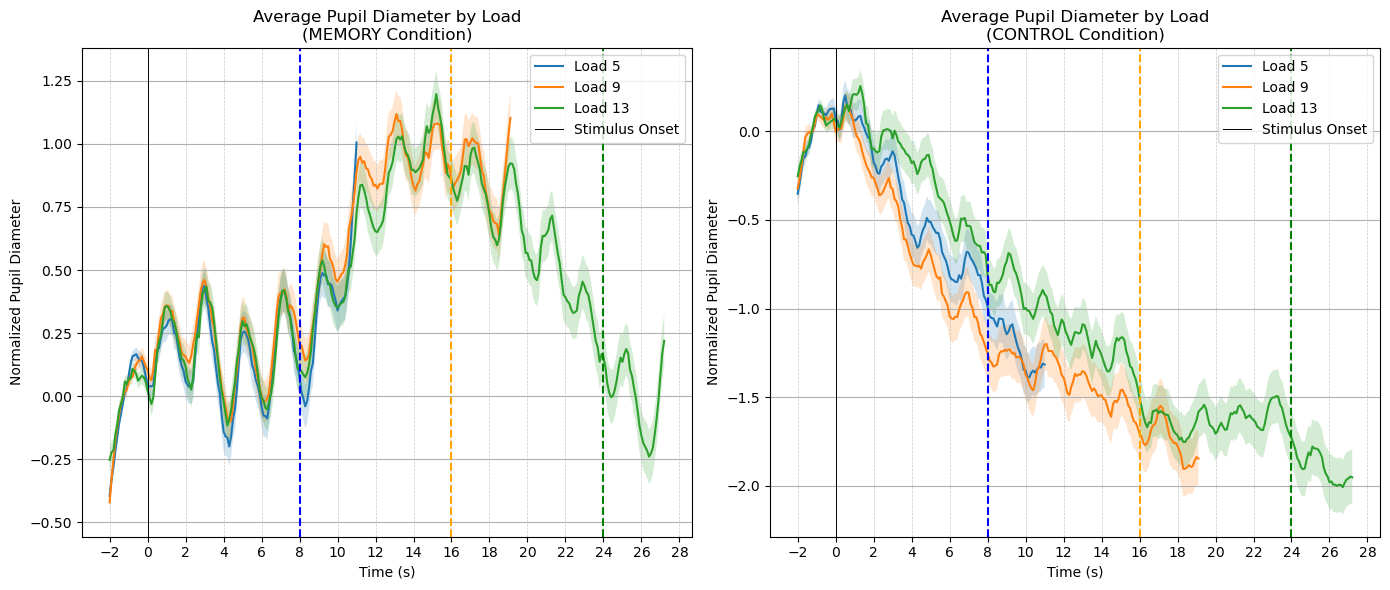

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for load in sorted(averaged_mem.keys()):
    mean_ts, sem_ts = averaged_mem[load] 
    axs[0].plot(mean_ts.index, mean_ts, label=f'Load {load}') 
    axs[0].fill_between(mean_ts.index, mean_ts - sem_ts, mean_ts + sem_ts, alpha=0.2) 
axs[0].set_xlabel("Time (s)") 
axs[0].set_ylabel("Normalized Pupil Diameter") 
axs[0].set_title("Average Pupil Diameter by Load\n(MEMORY Condition)") 
axs[0].axvline(0, color='k', linestyle='-', label='Stimulus Onset', linewidth=0.7) 
axs[0].axvline(8, color='b', linestyle='--') 
axs[0].axvline(16, color='orange', linestyle='--') 
axs[0].axvline(24, color='g', linestyle='--') 
axs[0].legend() 
axs[0].grid(True)
axs[0].set_xticks(ticks=np.arange(-2, 29, 2))
axs[0].grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)

for load in sorted(averaged_ctrl.keys()):
    mean_ts, sem_ts = averaged_ctrl[load] 
    axs[1].plot(mean_ts.index, mean_ts, label=f'Load {load}') 
    axs[1].fill_between(mean_ts.index, mean_ts - sem_ts, mean_ts + sem_ts, alpha=0.2)
axs[1].set_xlabel("Time (s)") 
axs[1].set_ylabel("Normalized Pupil Diameter") 
axs[1].set_title("Average Pupil Diameter by Load\n(CONTROL Condition)") 
axs[1].axvline(0, color='k', linestyle='-', label='Stimulus Onset', linewidth=0.7) 
axs[1].axvline(8, color='b', linestyle='--') 
axs[1].axvline(16, color='orange', linestyle='--') 
axs[1].axvline(24, color='g', linestyle='--') 
axs[1].legend() 
axs[1].grid(True)
axs[1].set_xticks(ticks=np.arange(-2, 29, 2))
axs[1].grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)    

plt.tight_layout() 
plt.show()

In [22]:
# Save the averaged data to a pickle file
with open("averaged_mem.pkl", "wb") as f: pkl.dump(averaged_mem, f)
with open("averaged_ctrl.pkl", "wb") as f: pkl.dump(averaged_ctrl, f)
# Save the epochs to a pickle file
with open("epochs.pkl", "wb") as f: pkl.dump(all_epochs, f)